# Prueba Análisis estadistico con Python 

In [336]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve,auc, precision_recall_curve, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler,RobustScaler,LabelEncoder
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

### 1. Carga los datos y explóralos. Elimina los datos nulos o incorrectos

In [337]:
# Cargamos el dataset
df = pd.read_csv("cardio.csv")

# Exploramos las primeras filas
df.head()

,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,M,39,4.0,No,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,F,46,2.0,No,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,M,48,1.0,Yes,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,F,61,3.0,Yes,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,F,46,3.0,Yes,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [338]:
# Verificamos la forma del DataFrame
df.shape

(4238, 16)

In [339]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sex              4238 non-null   object 
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   object 
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(5), object(2)
memory usage: 529.9+ KB


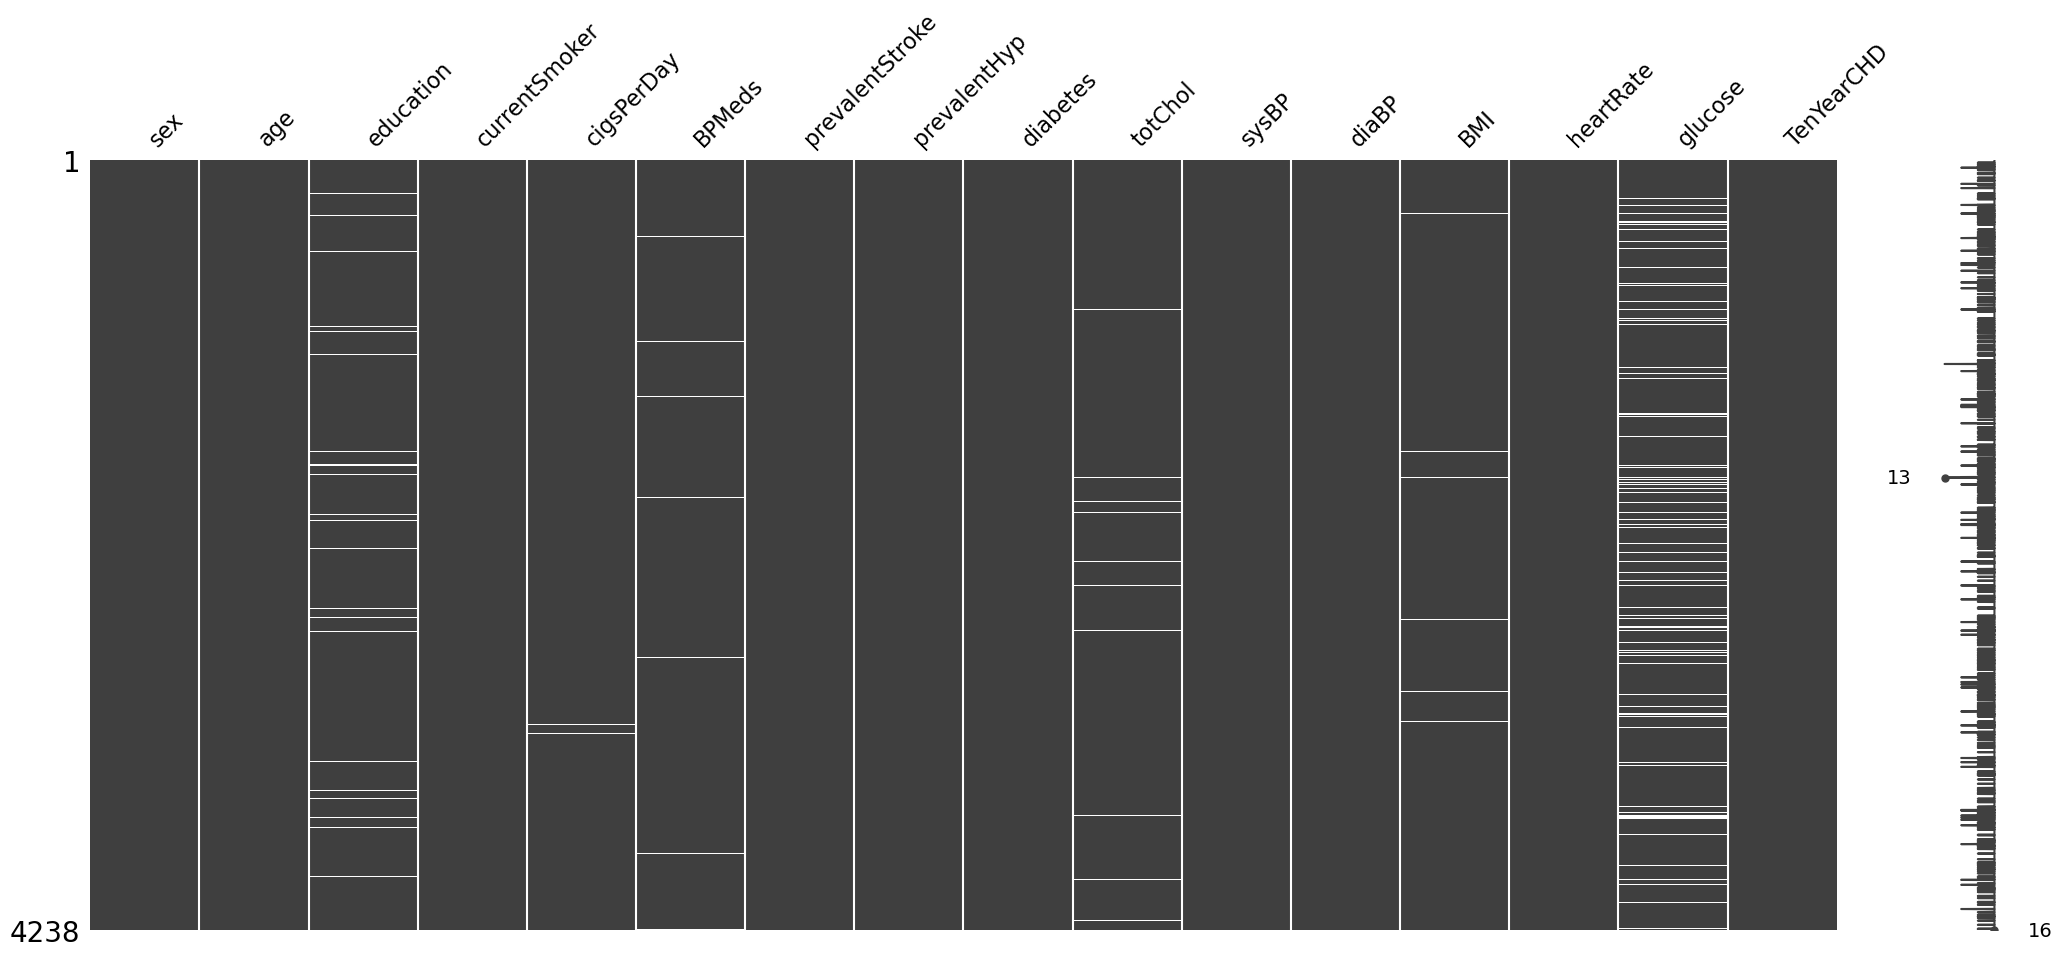

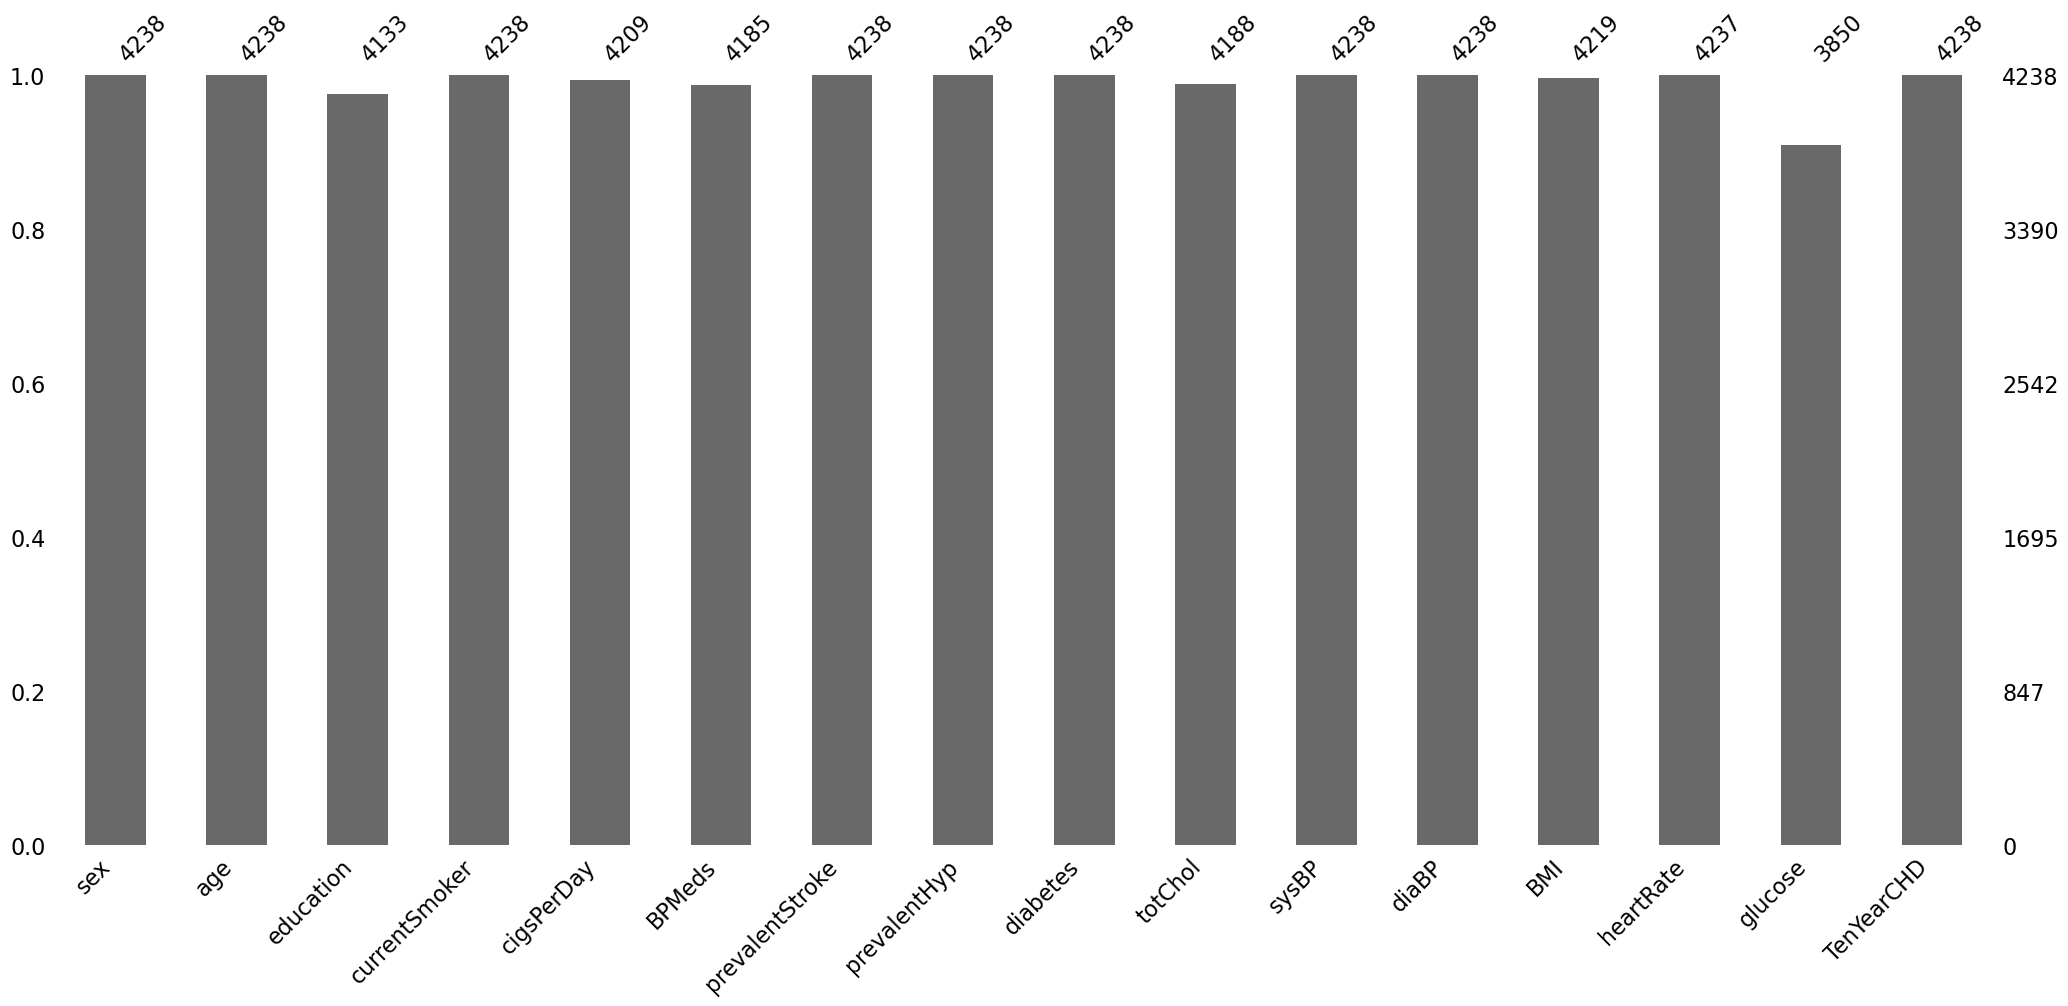

In [340]:
# Estadísticas descriptivas
msno.matrix(df)   # Genera un gráfico tipo matriz que visualiza la ausencia de valores en cada columna.
plt.show()        # mostramos el gráfico

msno.bar(df)      # Genera un gráfico de barras donde muestra el total de registros en cada columna
plt.show()        # mostramos el gráfico

In [341]:
# Eliminamos filas con valores nulos
df_clean = df.dropna()

# Verificamos que no queden nulos
df_clean.isnull().sum()

sex                0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

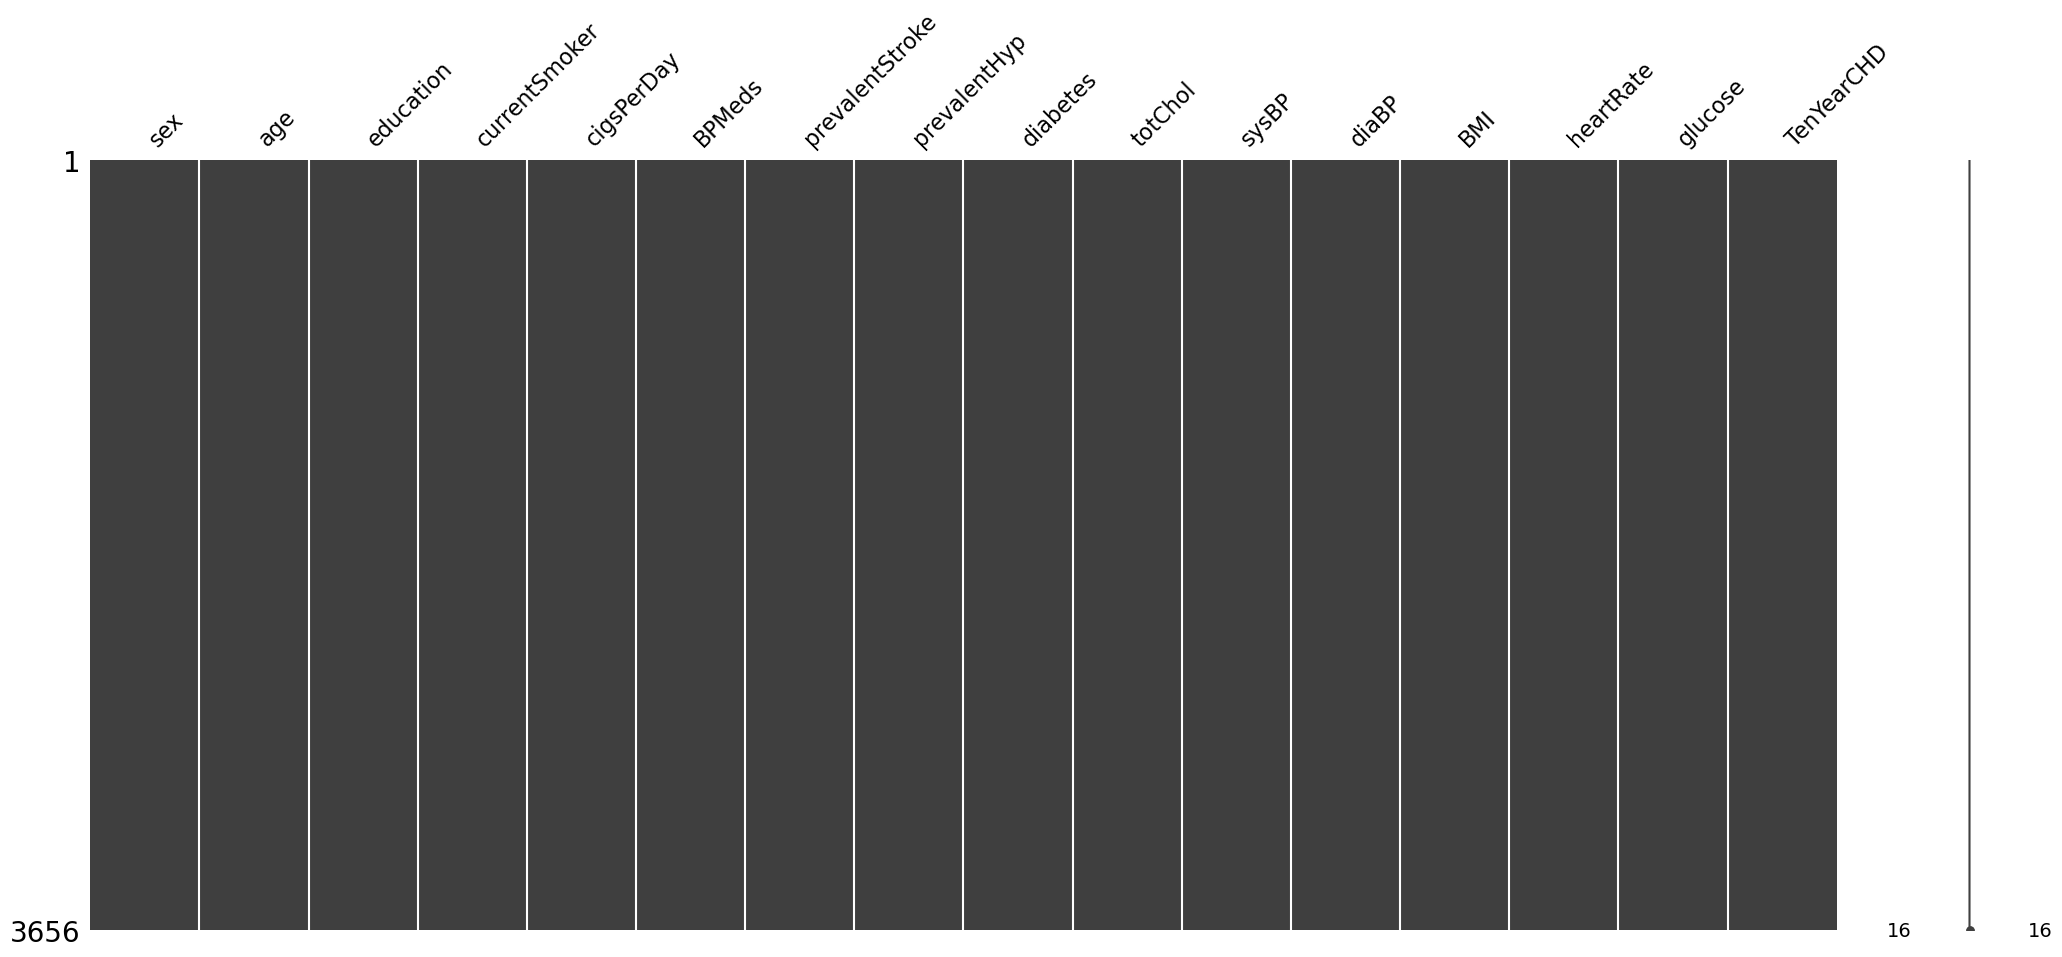

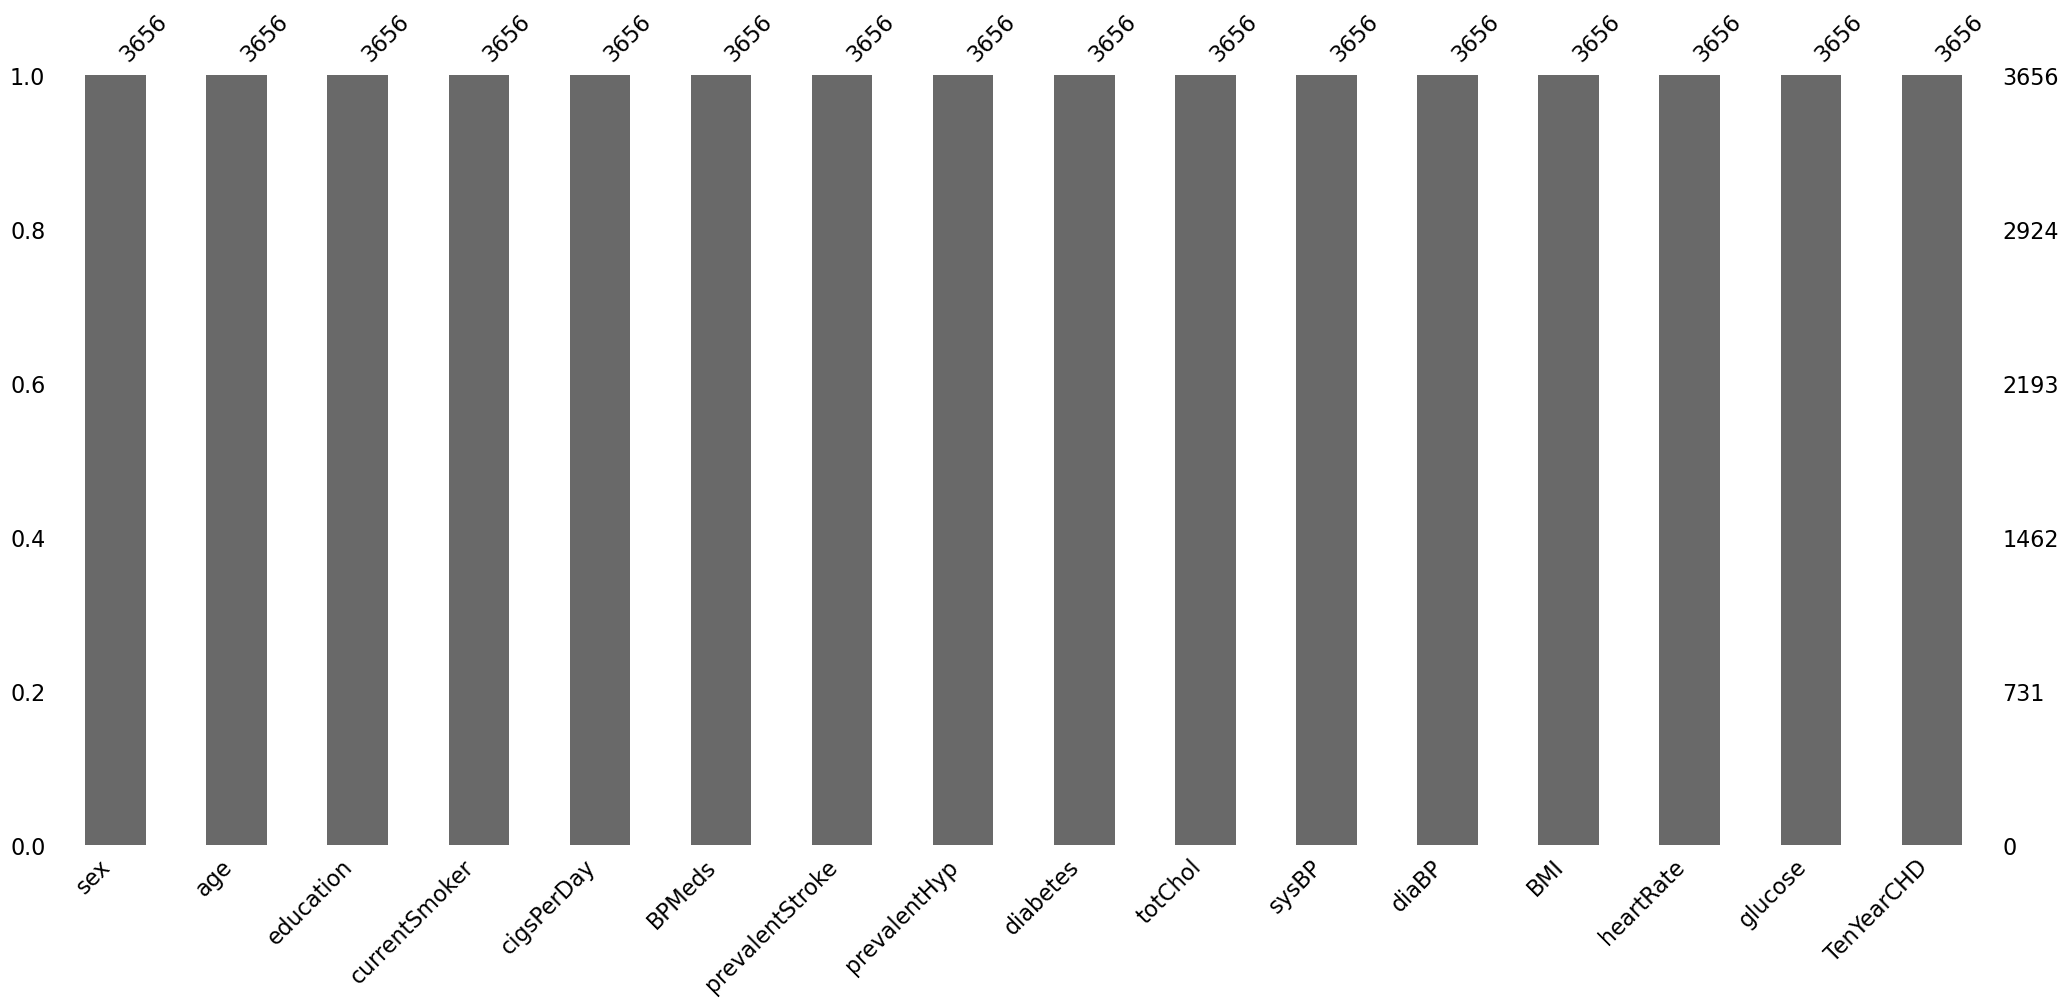

In [342]:
# Estadísticas descriptivas del DataFrame limpio
msno.matrix(df_clean)   # Genera un gráfico tipo matriz que visualiza la ausencia de valores en cada columna.
plt.show()              # mostramos el gráfico

msno.bar(df_clean)      # Genera un gráfico de barras donde muestra el total de registros en cada columna
plt.show()              # mostramos el gráfico

### 2. Escoge tres variables cuantitativas y realiza un análisis descriptivo de ellas,utilizando indicadores y gráficos. ¿Cuaĺ presenta mayor dispersión?

In [343]:
# Estadísticos descriptivos
df_clean[['BMI', 'sysBP', 'glucose']].describe().T

,count,mean,std,min,25%,50%,75%,max
BMI,3656.0,25.784185,4.065913,15.54,23.08,25.38,28.04,56.8
sysBP,3656.0,132.368025,22.092444,83.50,117.00,128.00,144.00,295.0
glucose,3656.0,81.856127,23.910128,40.00,71.00,78.00,87.00,394.0


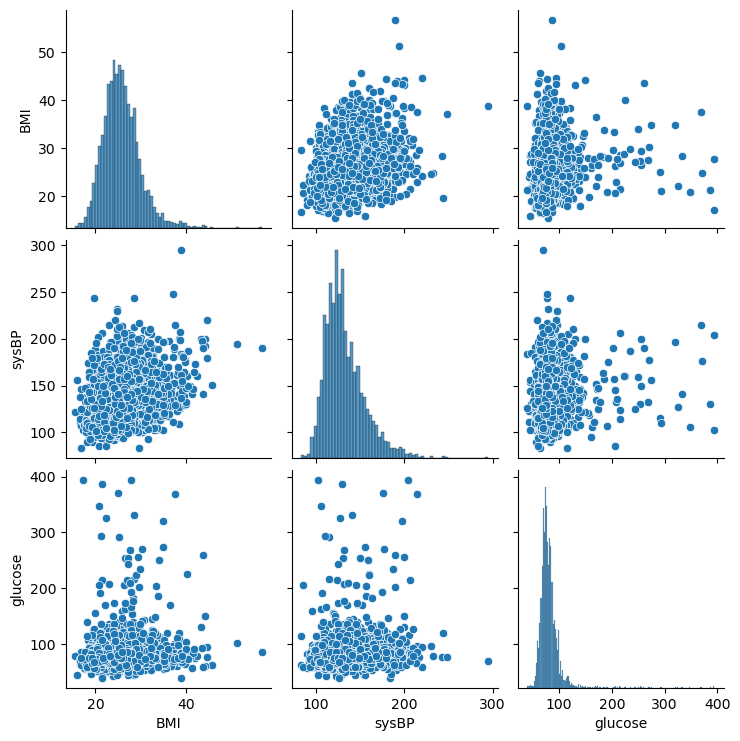

In [344]:
# Gráficos de dispersión
sns.pairplot(df_clean[['BMI', 'sysBP', 'glucose']])

plt.show()

### Respuesta
La variable glucose presenta mayor dispersión, evidenciada por su rango amplio y cola derecha pronunciada.

### 3. Elimina los datos atípicos del dataset. Para las siguientes preguntas, considera el dataset "limpio"

In [345]:
#aqui hacemos la funcion para eliminar outliers
def remove_outliers(df: pd.DataFrame, column: str):     # Se define una función llamada remove_outliers.
    """
    Devuelve una condición booleana para filtrar outliers
    utilizando el método IQR para una columna numérica.
    """
    Q1 = df[column].quantile(0.25)      # Calcula el primer cuartil (Q1) de la columna, es decir, el valor por debajo del cual está el 25% de los datos.
    Q3 = df[column].quantile(0.75)      # Calcula el tercer cuartil (Q3), el valor por debajo del cual está el 75% de los datos.
    IQR = Q3 - Q1                       # Calcula el rango intercuartílico (IQR): diferencia entre Q3 y Q1.
    # Define los límites “aceptables” según la regla clásica del IQR:
    MIN = Q1 - 1.5 * IQR    # límite inferior → valores por debajo se consideran outliers bajos.
    MAX = Q3 + 1.5 * IQR    # límite superior → valores por encima se consideran outliers altos.
    
    condicion = (df[column] > MIN) & (df[column] < MAX) # Define condicion para saber si el valor de la columna esta dentro del MIN y MAX
    
    return condicion    # Devuelve la condición

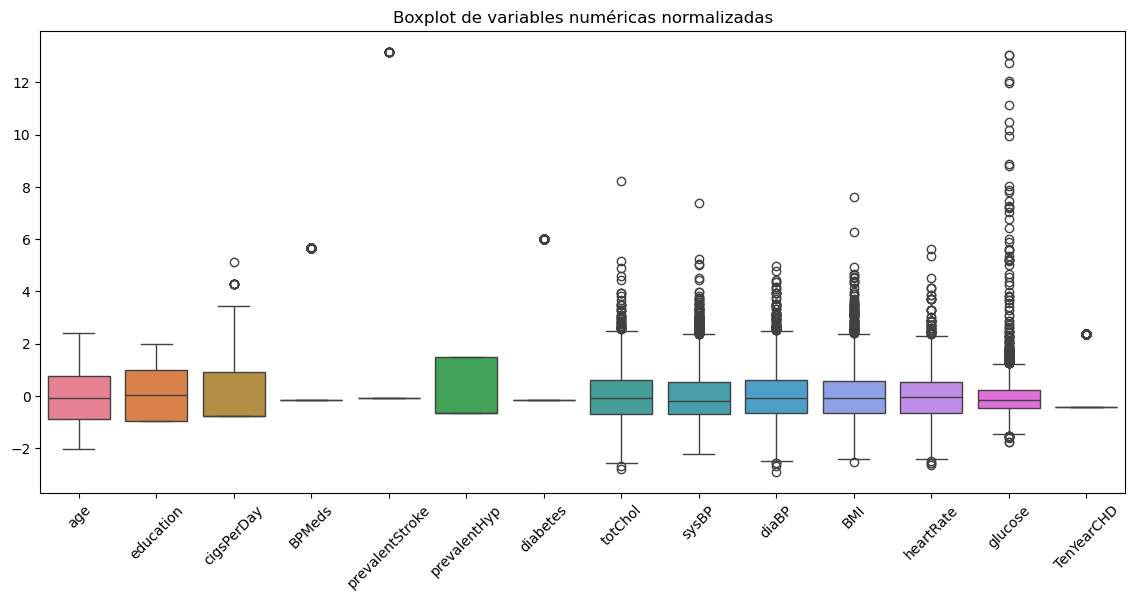

In [346]:
# Seleccionar solo variables numéricas
df_num = df_clean.select_dtypes(include='number')

scaler = StandardScaler()         # Inicializa el objeto StandardScaler para normalizar los datos.
df_scaled = pd.DataFrame(         # Crea un nuevo DataFrame con los datos normalizados.
    scaler.fit_transform(df_num), # Aplica la normalización a los datos numéricos.
    columns=df_num.columns        # Mantiene los nombres originales de las columnas.
)

plt.figure(figsize=(14,6))                                # Configura el tamaño de la figura del gráfico.
sns.boxplot(data=df_scaled)                               # Crea un boxplot para visualizar la distribución de las variables normalizadas.
plt.xticks(rotation=45)                                   # Rota las etiquetas del eje x para mejor legibilidad.
plt.title("Boxplot de variables numéricas normalizadas")  # Añade un título al gráfico.
plt.show()                                                # Muestra el gráfico.



El boxplot muestra las variables numéricas estandarizadas del conjunto de datos. Se observa una mayor dispersión y presencia de valores atípicos en variables continuas como colesterol total, presión arterial y glucosa. Las variables binarias presentan distribuciones concentradas, lo cual es esperable tras el proceso de normalización.

In [347]:
cols_outliers = [
    "age", "cigsPerDay", "totChol",
    "sysBP", "diaBP", "BMI",
    "heartRate", "glucose"
]

df_cleaner = df_clean.copy() # Creamos una copia del DataFrame limpio para eliminar outliers

for col in cols_outliers:
    df_cleaner = df_cleaner[ remove_outliers(df_cleaner, col) ]

print("Filas originales:", df_clean.shape[0])
print("Filas después de limpiar:", df_cleaner.shape[0])

Filas originales: 3656
Filas después de limpiar: 3161


Desde aca empezaremos a utilizar df_cleaner como un dataset limpio, tal y como lo pide el desafio

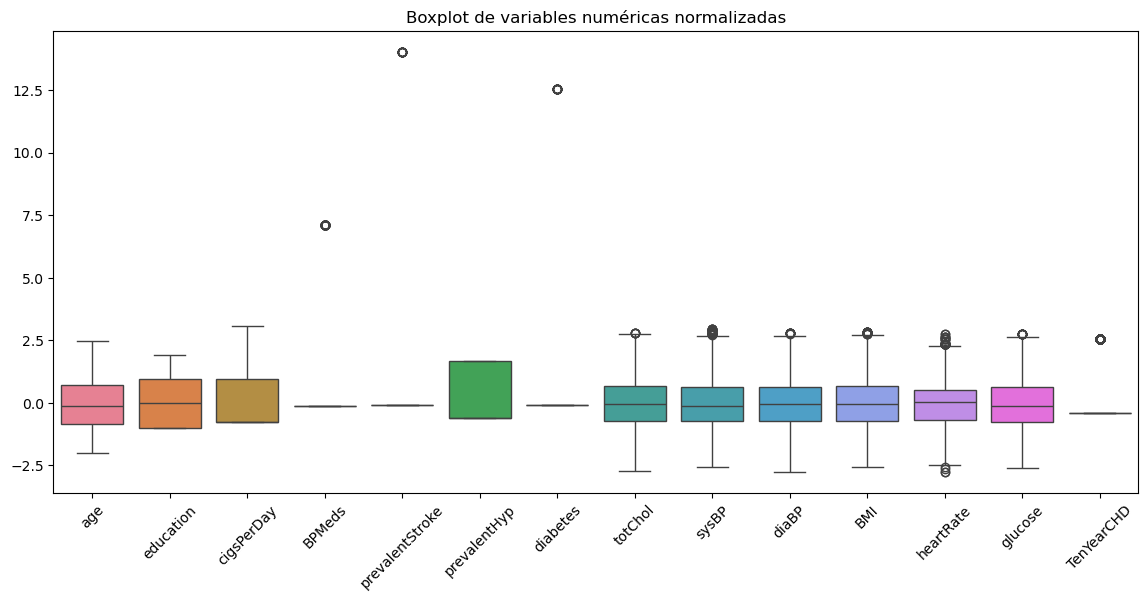

In [348]:
# Seleccionar solo variables numéricas
df_num_l = df_cleaner.select_dtypes(include='number')

scaler = StandardScaler()           # Inicializa el objeto StandardScaler para normalizar los datos.
df_scaled = pd.DataFrame(           # Crea un nuevo DataFrame con los datos normalizados.
    scaler.fit_transform(df_num_l),   # Aplica la normalización a los datos numéricos.
    columns=df_num_l.columns          # Mantiene los nombres originales de las columnas.
)

plt.figure(figsize=(14,6))                                  # Configura el tamaño de la figura del gráfico.
sns.boxplot(data=df_scaled)                                 # Crea un boxplot para visualizar la distribución de las variables normalizadas.
plt.xticks(rotation=45)                                     # Rota las etiquetas del eje x para mejor legibilidad.
plt.title("Boxplot de variables numéricas normalizadas")    # Añade un título al gráfico.
plt.show()                                                  # Muestra el gráfico.


### 4. ¿Qué variables cuantitativas presentan mayor correlación? Explica.

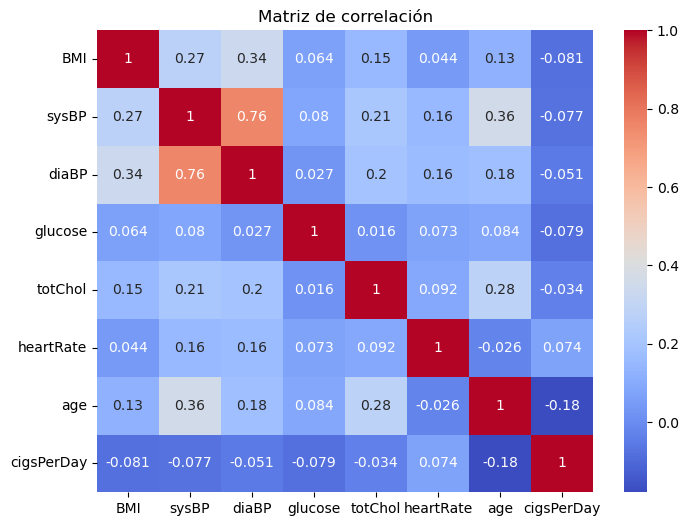

In [349]:
# Matriz de correlación
corr = df_cleaner[['BMI', 'sysBP', 'diaBP', 'glucose', 'totChol', 'heartRate', 'age', 'cigsPerDay']].corr() # Calcula la matriz de correlación para las columnas especificadas del DataFrame df_cleaner.

plt.figure(figsize=(8,6))                        # Configura el tamaño de la figura del gráfico.
sns.heatmap(corr, annot=True, cmap="coolwarm")   # Crea un mapa de calor (heatmap) para visualizar la matriz de correlación, con anotaciones y un esquema de colores "coolwarm".
plt.title("Matriz de correlación")               # Añade un título al gráfico.
plt.show()                                       # Muestra el gráfico.


### Respuesta 
A partir de la matriz de correlación se observa que la mayor correlación positiva se presenta entre sysBP y diaBP (r = 0.76), lo cual es esperable ya que ambas variables corresponden a mediciones de la presión arterial.

También se identifican correlaciones positivas moderadas entre age y sysBP (r = 0.36), y entre BMI y diaBP (r = 0.34), lo que sugiere que la presión arterial tiende a aumentar tanto con la edad como con el índice de masa corporal.

### 5. Si de este dataset se escoge un paciente al azar, ¿cuál es la probabilidad de que sea hombre, si se sabe que pertenece al mayor cuartil de la variable correspondiente al índice de masa corporal?

In [350]:
# Cuartil superior de BMI
q3_bmi = df_cleaner['BMI'].quantile(0.75)

# Filtramos personas en el cuartil superior
df_bmi_alto = df_cleaner[df_cleaner['BMI'] >= q3_bmi]

# Probabilidad condicional
prob_hombre = (df_bmi_alto['sex'] == 'M').mean()
prob_hombre


np.float64(0.5347661188369153)

La probabilidad de que un paciente sea hombre dado que pertenece al cuartil superior de BMI es del 53%.

### 6. ¿Es razonable afirmar que, para una persona cualquiera (no necesariamente dentro del dataset), su ritmo cardiaco promedio es 75? Explica y justifica.

Hipótesis nula (H₀):
El ritmo cardiaco promedio es 75

𝐻0 : 𝜇 = 75

Hipótesis alternativa (H₁):
El ritmo cardiaco promedio es distinto de 75

𝐻1 : 𝜇 ≠ 75

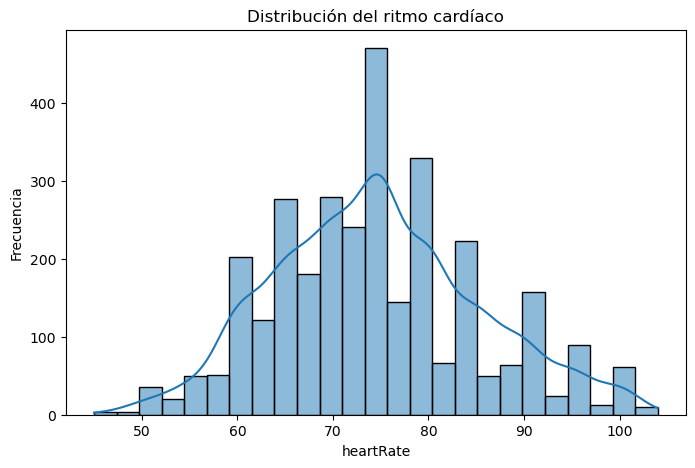

In [351]:
# Crea una figura de tamaño 8x5 pulgadas 
plt.figure(figsize=(8,5))
sns.histplot(df_cleaner["heartRate"],  # Histograma del ritmo cardíaco con línea de densidad (kde)
             kde=True,                 # kde=True agrega una curva suavizada que muestra la distribución
             bins=25,                  # bins=25 define el número de barras del histograma
             edgecolor="black"         # edgecolor="black" dibuja el borde de cada barra para mayor claridad
             )        
plt.title("Distribución del ritmo cardíaco") # Título del gráfico
plt.xlabel("heartRate")                      # Etiqueta del eje X (variable representada)
plt.ylabel("Frecuencia")                     # Etiqueta del eje Y (frecuencia)
plt.show()                                   # Muestra el gráfico en pantalla

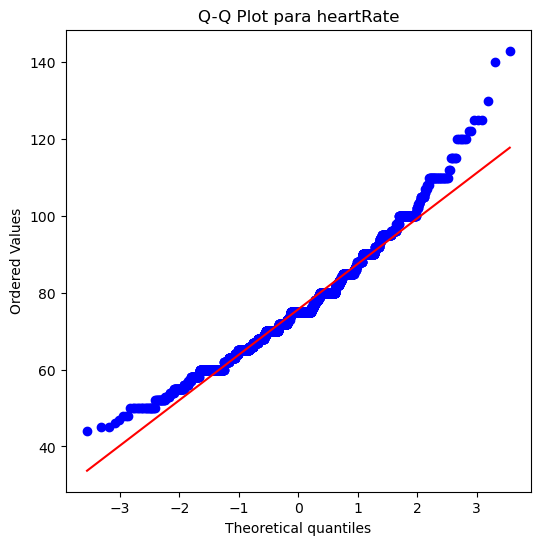

In [352]:
plt.figure(figsize=(6,6))                # Crea una figura cuadrada de 6x6 pulgadas para el Q-Q plot
# Genera un Q-Q Plot (Quantile-Quantile)
stats.probplot(df_clean["heartRate"],    # stats.probplot compara los cuantiles de los datos con los cuantiles de una distribución normal
               dist="norm",              # dist="norm" indica que queremos compararlo contra una distribución normal teórica
               plot=plt                  # plot=plt dibuja el gráfico usando matplotlib
               )                 
plt.title("Q-Q Plot para heartRate")     # Título del gráfico
plt.show()                               # Muestra la figura

In [353]:
# Prueba t de una muestra
t_stat, p_value = stats.ttest_1samp(df_cleaner['heartRate'], 75)

t_stat, p_value


(np.float64(-2.310189373512855), np.float64(0.02094179573119326))

##### p-value ≈ 0.02094 < 0.05

##### Esto implica que estadísticamente se rechaza la hipótesis nula de normalidad 𝐻0 : 𝜇 = 75.

### 7. Ser hombre, ¿influye en el promedio de cigarrillos consumidos por día, dentro de los pacientes fumadores? Explica.

In [354]:
# Filtramos solo fumadores
df_smokers = df_cleaner[df_cleaner['currentSmoker'] == 'Yes'].copy()

# Separación por sexo
cigs_m = df_smokers[df_smokers['sex'] == 'M']['cigsPerDay']
cigs_f = df_smokers[df_smokers['sex'] == 'F']['cigsPerDay']

# Prueba t para muestras independientes
t_stat, p_value = stats.ttest_ind(cigs_m, cigs_f, equal_var=False)

# Resultados
print("t_stat =", t_stat, "p_value =", p_value)

# Resumen estadístico
summary = df_smokers.groupby('sex')['cigsPerDay'].agg(
    total='count',
    mean='mean',
    std='std'
)

# Resumen estadístico
summary

t_stat = 16.479464348692343 p_value = 2.307327122416164e-56


,total,mean,std
sex,,,
F,697,13.997131,8.635166
M,868,21.789171,10.059822


##### Respuesta:
Para evaluar si ser hombre influye en el promedio de cigarrillos consumidos por día dentro de los pacientes fumadores, se consideraron únicamente los individuos que declararon ser fumadores actuales. Se comparó el consumo promedio diario entre hombres y mujeres mediante una prueba t para muestras independientes.

Los resultados muestran que los hombres fumadores consumen en promedio 21.79 cigarrillos por día, mientras que las mujeres fumadoras consumen 13.99. La diferencia observada es estadísticamente significativa (t = 16.47, p < 0.05), lo que indica que el consumo promedio diario de cigarrillos difiere según el sexo, siendo mayor en los hombres fumadores.

### 8. Construye un modelo de regresión lineal que permita relacionar 6 variables del dataset con el índice de masa corporal. (Debes incluir al menos dos variables cualitativas). Evalúa tu modelo y explica.

In [355]:
# Seleccionar variables (6 predictoras + BMI)
df_multi = df_cleaner[['BMI', 'diaBP', 'glucose', 'sex', 'currentSmoker', 'totChol', 'prevalentHyp']].dropna().copy()

# Normalizar categóricas
df_multi['sex'] = df_multi['sex'].astype(str).str.strip().str.upper()
df_multi['currentSmoker'] = df_multi['currentSmoker'].astype(str).str.strip().str.title()  # 'Yes'/'No'

# Dummies (2 cualitativas)
df_multi = pd.get_dummies(df_multi, columns=['sex', 'currentSmoker'], drop_first=True)

# Separar X e Y
y = df_multi['BMI'].astype(float)
X = df_multi.drop(columns='BMI')

# Convertir todo a float (incluye bool -> 0.0/1.0)
X = X.astype(float)

# Constante e OLS
X = sm.add_constant(X)
model_multi = sm.OLS(y, X).fit()

# Resumen del modelo
print(model_multi.summary())

# Predicciones y métricas
y_pred = model_multi.predict(X)

mse = ((y - y_pred) ** 2).mean()        # Mean Squared Error
mae = (y - y_pred).abs().mean()         # Mean Absolute Error
rmse = np.sqrt(mse)                     # Root Mean Squared Error
emse = mse / ((y - y.mean())**2).mean() # Explained Mean Squared Error

# Resultados
print(f"R²: {model_multi.rsquared:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"EMSE: {emse:.2f}")

                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     101.2
Date:                Fri, 09 Jan 2026   Prob (F-statistic):          8.28e-117
Time:                        16:58:25   Log-Likelihood:                -8120.3
No. Observations:                3161   AIC:                         1.625e+04
Df Residuals:                    3154   BIC:                         1.630e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                15.6895      0.73

Interpretación de las variables

* Presión diastólica (diaBP = +0.082, p < 0.001)
Existe una relación clara y estadísticamente significativa: las personas con mayor presión diastólica tienden a tener un BMI más alto.

* Glucosa (glucose = +0.013, p = 0.012)
A mayor nivel de glucosa en sangre, el BMI tiende a ser ligeramente mayor. Aunque el efecto es pequeño, la asociación es estadísticamente significativa.

* Colesterol total (totChol = +0.008, p < 0.001)
Las personas con colesterol total más alto presentan, en promedio, un BMI mayor, y esta relación es estadísticamente significativa.

* Hipertensión (prevalentHyp = +0.52, p = 0.001)
Las personas con hipertensión tienen un BMI aproximadamente 0.5 puntos mayor que las personas sin hipertensión, diferencia que es significativa.

* Sexo masculino (sex_M = +1.06, p < 0.001)
Ser hombre se asocia con un BMI cerca de 1 punto mayor en comparación con las mujeres, manteniendo constantes las demás variables. Esta diferencia es estadísticamente significativa.

* Ser fumador actual (currentSmoker_Yes = −1.02, p < 0.001)
Los fumadores actuales presentan, en promedio, un BMI cerca de 1 punto menor que los no fumadores, asociación que resulta estadísticamente significativa.

* Resumen Todas las variables incluidas muestran asociaciones estadísticamente significativas con el BMI (p < 0.05), indicando que factores cardiovasculares, metabólicos y conductuales se relacionan con diferencias en el índice de masa corporal.
### Conclusion
Se estimó un modelo de regresión lineal para explicar el BMI utilizando seis variables explicativas, incluyendo dos cualitativas (sexo y condición de fumador). El modelo resultó globalmente significativo (p < 0.05) y explicó aproximadamente el 16% de la variabilidad del BMI. Todas las variables incluidas fueron estadísticamente significativas. La presión diastólica, la glucosa, el colesterol total y la presencia de hipertensión se asociaron positivamente con el BMI, mientras que el sexo masculino mostró una asociación positiva y ser fumador una asociación negativa. El error típico de predicción fue cercano a 3.16 unidades de BMI.

### 9. Construye un modelo de regresión logística para predecir el riesgo de sufrir una enfermedad coronaria en los próximos diez años, a partir de las variables descritas. Verifica el balanceo de datos y evalúa tu modelo.

In [356]:
# Seleccionar variables y eliminar NaN
df_log = df_cleaner.dropna().copy()

# Normalizar categóricas
df_log['sex'] = df_log['sex'].astype(str).str.strip().str.upper()
df_log['currentSmoker'] = df_log['currentSmoker'].astype(str).str.strip().str.title()

# Variables dummy (categorías → numéricas)
df_log = pd.get_dummies(df_log, columns=['sex', 'currentSmoker'], drop_first=True)

# Separar X e y
X = df_log.drop(columns=['TenYearCHD'])
y = df_log['TenYearCHD']   # YA es 0/1, NO hay que mapear

# Crear y entrenar el modelo
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=2000))
])

# Entrenamiento
pipeline.fit(X, y)

# Predicciones
y_pred = pipeline.predict(X)

# Evaluación
print(f"Precisión del modelo: {accuracy_score(y, y_pred):.3f}")
print("Matriz de Confusión:")
print(confusion_matrix(y, y_pred))
print("Informe de Clasificación:")
print(classification_report(y, y_pred))


Precisión del modelo: 0.869
Matriz de Confusión:
[[2733   10]
 [ 403   15]]
Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      2743
           1       0.60      0.04      0.07       418

    accuracy                           0.87      3161
   macro avg       0.74      0.52      0.50      3161
weighted avg       0.84      0.87      0.82      3161



De 418 personas con CHD (1):

Solo 15 fueron detectadas correctamente

403 fueron clasificadas como sanas

AUC-ROC: 0.7335775972593135
AUC-PR: 0.30709049821290546


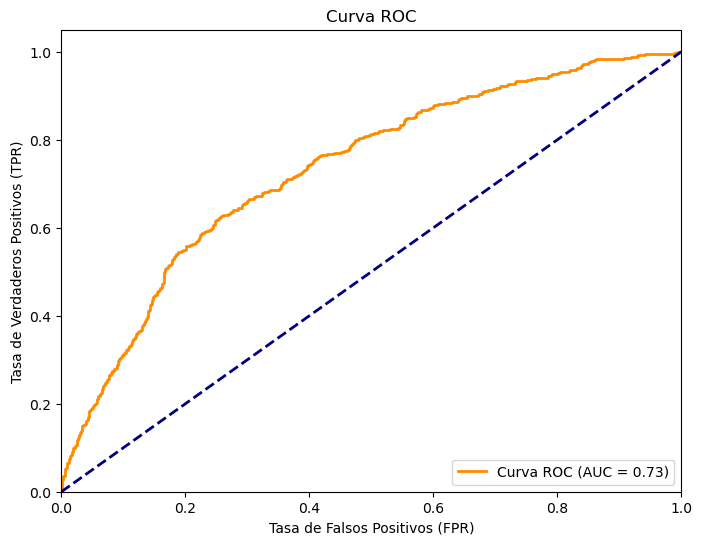

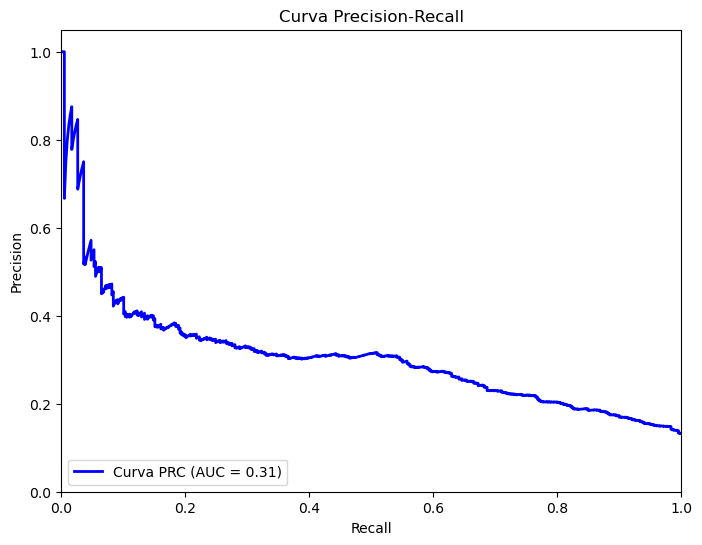

In [357]:
# Obtener las probabilidades de predicción
y_prob = pipeline.predict_proba(X)[:, 1]

# Calcular el AUC-ROC
roc_auc = roc_auc_score(y, y_prob)
print(f'AUC-ROC: {roc_auc}')

# Calcular el AUC-PR
prc_auc = average_precision_score(y, y_prob)
print(f'AUC-PR: {prc_auc}')

# Calcular la curva ROC
fpr, tpr, thresholds_roc = roc_curve(y, y_prob)

# Calcular la curva PRC
precision, recall, thresholds_prc = precision_recall_curve(y, y_prob)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')

# Graficar la curva PRC
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label='Curva PRC (AUC = %0.2f)' % prc_auc)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend(loc='lower left')

# Mostrar las curvas ROC y PRC
plt.show()

Si tomo un paciente con CHD y uno sin CHD al azar, el modelo asigna mayor probabilidad al paciente con CHD en el 73% de los casos.

Verificamos desbalance de clases

In [358]:
# Cargamos los datos
df_balance= df_cleaner.copy()
# Eliminamos Duplicados
df_balance.drop_duplicates(inplace=True)

# Eliminamos Nulos, y los datos "Time" y "Amount" por no estar correctamente codificadas
df_dlt=df_balance.dropna()
df_dlt=df_dlt.drop(['sex','currentSmoker'] , axis = 1)
col=df_dlt.columns.to_list()

# Identifiquemos las variables X e y
X=df_dlt.drop('TenYearCHD', axis = 1)
Y=df_dlt['TenYearCHD']

# Es necesario escalar las características
sc=StandardScaler()
X=sc.fit_transform(X)

# Verifiquemos el desbalanceo de clases
print(df_dlt['TenYearCHD'].value_counts())

TenYearCHD
0    2743
1     418
Name: count, dtype: int64


Podemos observar que las clases estan totalmente desbalanceada 

### Balanceando clases con class_weight='balanced'

In [359]:
# Seleccionar variables y eliminar NaN
df_log_m = df_cleaner.dropna().copy()

# Normalizar categóricas
df_log_m['sex'] = df_log_m['sex'].astype(str).str.strip().str.upper()
df_log_m['currentSmoker'] = df_log_m['currentSmoker'].astype(str).str.strip().str.title()

# Variables dummy (categorías → numéricas)
df_log_m = pd.get_dummies(df_log_m, columns=['sex', 'currentSmoker'], drop_first=True)

# Separar X e y
X = df_log_m.drop(columns=['TenYearCHD'])
y = df_log_m['TenYearCHD']   # YA es 0/1, NO hay que mapear

# Crear y entrenar el modelo
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(class_weight='balanced', max_iter=2000)) # añadimos class_weight al modelo
])

# Entrenamiento
pipeline.fit(X, y)

# Predicciones
y_pred = pipeline.predict(X)

# Evaluación
print(f"Precisión del modelo: {accuracy_score(y, y_pred):.3f}")
print("Matriz de Confusión:")
print(confusion_matrix(y, y_pred))
print("Informe de Clasificación:")
print(classification_report(y, y_pred))

Precisión del modelo: 0.670
Matriz de Confusión:
[[1835  908]
 [ 134  284]]
Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.93      0.67      0.78      2743
           1       0.24      0.68      0.35       418

    accuracy                           0.67      3161
   macro avg       0.59      0.67      0.57      3161
weighted avg       0.84      0.67      0.72      3161



Ahora de 418 personas con CHD (1):

284 fueron detectadas correctamente y 134 fueron clasificadas como sanas

Cambiamos umbral (threshold)

In [360]:
# Ajuste del umbral de clasificación
y_prob = pipeline.predict_proba(X)[:, 1]            # Obtiene las probabilidades de pertenecer a la clase positiva
threshold = 0.3                                     # nuevo umbral
y_pred_custom = (y_prob >= threshold).astype(int)   # Convierte las probabilidades en predicciones binarias según el umbral

# Evaluación con nuevo umbral
print(f"Umbral usado: {threshold}")
print("Matriz de Confusión:")
print(confusion_matrix(y, y_pred_custom))
print("Reporte de Clasificación:")
print(classification_report(y, y_pred_custom))



Umbral usado: 0.3
Matriz de Confusión:
[[ 877 1866]
 [  39  379]]
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.96      0.32      0.48      2743
           1       0.17      0.91      0.28       418

    accuracy                           0.40      3161
   macro avg       0.56      0.61      0.38      3161
weighted avg       0.85      0.40      0.45      3161



Al ajustar el umbral de decisión a 0.3 y utilizar pesos balanceados, el modelo logra una alta sensibilidad (recall ≈ 0.91) en la detección de pacientes con enfermedad coronaria, reduciendo significativamente los falsos negativos. Sin embargo, esto se logra a costa de una baja precisión y una disminución de la exactitud global, debido al aumento de falsos positivos. Este comportamiento es esperado en problemas clínicos desbalanceados y resulta adecuado para contextos de detección temprana.

### Balanceando clases con Smote

In [361]:
# Seleccionar columnas relevantes y eliminar NaN
df_log_smote = df_cleaner.dropna().copy()

# Normalizar categóricas
df_log_smote['sex'] = df_log_smote['sex'].astype(str).str.strip().str.upper()
df_log_smote['currentSmoker'] = df_log_smote['currentSmoker'].astype(str).str.strip().str.title()

# Pasar categóricas a numéricas (dummies)
df_log_smote = pd.get_dummies(df_log_smote, columns=['sex', 'currentSmoker'], drop_first=True)

# Separar X e y
X = df_log_smote.drop(columns=["TenYearCHD"])
y = df_log_smote["TenYearCHD"]

# Train / Test split (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Entrenamiento con SMOTE dentro del pipeline
pipeline_smote = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('logreg', LogisticRegression(max_iter=2000))
])

# Entrenamos el modelo
pipeline_smote.fit(X_train, y_train)    # Entrenamiento

# Probabilidades en test
y_prob = pipeline_smote.predict_proba(X_test)[:, 1] # obtenemos las probabilidades de la clase positiva

# Métricas correctas
roc_auc = roc_auc_score(y_test, y_prob)             # AUC-ROC
pr_auc = average_precision_score(y_test, y_prob)    # AUC-PR

# Resultados
print(f"AUC-ROC con SMOTE: {roc_auc:.3f}")
print(f"AUC-PR con SMOTE: {pr_auc:.3f}")

# Clasificación con umbral ajustable
threshold = 0.3                             # nuevo umbral
y_pred = (y_prob >= threshold).astype(int)  # convertimos a 0/1 según el umbral

# Resultados con umbral ajustado
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))
print("Reporte:")
print(classification_report(y_test, y_pred))


AUC-ROC con SMOTE: 0.772
AUC-PR con SMOTE: 0.324
Matriz de Confusión:
[[258 566]
 [  9 116]]
Reporte:
              precision    recall  f1-score   support

           0       0.97      0.31      0.47       824
           1       0.17      0.93      0.29       125

    accuracy                           0.39       949
   macro avg       0.57      0.62      0.38       949
weighted avg       0.86      0.39      0.45       949



Se construyó un modelo de regresión logística para predecir el riesgo de enfermedad coronaria a 10 años (TenYearCHD), utilizando variables clínicas, metabólicas y conductuales.
Las variables categóricas (sex y currentSmoker) fueron transformadas a variables dummy y las variables numéricas estandarizadas.

Dado que el conjunto de datos presentaba desbalance de clases (menor proporción de pacientes con enfermedad coronaria), se aplicó SMOTE únicamente sobre el conjunto de entrenamiento, con el fin de generar observaciones sintéticas de la clase minoritaria y mejorar la capacidad predictiva del modelo.

Evaluación del modelo con SMOTE

AUC-ROC: 0.77

AUC-PR: 0.32

Recall clase positiva: 0.93 (con umbral 0.3)

El aumento del AUC-ROC respecto al modelo sin balanceo indica una mejor discriminación entre pacientes con y sin riesgo.
Al ajustar el umbral de decisión a 0.3, se prioriza la detección de pacientes en riesgo, logrando un alto recall a costa de una menor precisión, lo cual es adecuado en un contexto preventivo en salud.

Conclusión

El uso de SMOTE permitió mejorar la detección de pacientes con riesgo coronario, aumentando significativamente la sensibilidad del modelo. Aunque se incrementan los falsos positivos, el modelo resulta más apropiado como herramienta de screening clínico, donde es preferible identificar posibles casos de riesgo antes que omitirlos.

### 10. Separa los modelos de regresión anteriores en dos distintos, respectivamente, considerando alguna variable categórica. Compara y concluye.

### 1. Modelo Regresion Lineal

In [362]:
# Modelos lineales por sexo (BMI)
# Iteramos por cada sexo
for sex in ['M', 'F']:  
    df_sexo = df_cleaner[df_cleaner['sex'] == sex].copy()

    # Normalizar currentSmoker
    df_sexo['currentSmoker'] = df_sexo['currentSmoker'].astype(str).str.strip().str.title()

    # Seleccionar columnas usadas y eliminar NaN
    cols = ['BMI', 'diaBP', 'glucose', 'totChol', 'prevalentHyp', 'currentSmoker']
    df_sexo = df_sexo[cols].dropna().copy()

    # Separar X e Y
    X = df_sexo[['diaBP', 'glucose', 'totChol', 'prevalentHyp', 'currentSmoker']]
    y = df_sexo['BMI']

    # Dummies para currentSmoker
    X = pd.get_dummies(X, columns=['currentSmoker'], drop_first=True)

    # Forzar numérico en X y en y
    X = X.apply(pd.to_numeric, errors='coerce')
    y = pd.to_numeric(y, errors='coerce')

    # Alinear y limpiar NaN generados
    data = pd.concat([y.rename('BMI'), X], axis=1).dropna()
    y = data['BMI'].astype(float)
    X = data.drop(columns=['BMI']).astype(float)

    # OLS
    X = sm.add_constant(X)
    model_lin = sm.OLS(y, X).fit()

    # Predicciones y métricas
    y_pred = model_lin.predict(X)   

    mse = ((y - y_pred) ** 2).mean()            # Mean Squared Error
    mae = (y - y_pred).abs().mean()             # Mean Absolute Error
    rmse = np.sqrt(mse)                         # Root Mean Squared Error
    emse = mse / ((y - y.mean())**2).mean()     # Explained Mean Squared Error

    # Resultados
    print(f"R²: {model_lin.rsquared:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"EMSE: {emse:.2f}")
    print(f"\n=== Modelo lineal (BMI) para sexo {sex} ===")
    print(model_lin.summary())

R²: 0.13
MSE: 8.69
RMSE: 2.95
MAE: 2.35
EMSE: 0.87

=== Modelo lineal (BMI) para sexo M ===
                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.129
Model:                            OLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     42.28
Date:                Fri, 09 Jan 2026   Prob (F-statistic):           1.05e-40
Time:                        16:58:25   Log-Likelihood:                -3587.8
No. Observations:                1435   AIC:                             7188.
Df Residuals:                    1429   BIC:                             7219.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------

Al estimar modelos de regresión lineal separados por sexo, se observan diferencias tanto en las métricas de ajuste como en las variables significativas. En mujeres, el modelo presenta mayor capacidad explicativa y un mayor número de factores relevantes, mientras que en hombres el efecto se concentra principalmente en la presión diastólica, colesterol y condición de fumador. Esto indica que la relación entre factores cardiovasculares y BMI no es homogénea entre sexos, justificando el uso de modelos separados.

### 2. Modelo Regresion Logistico

In [363]:
# Modelos logísticos por sexo (TenYearCHD)
resultados = {}     # Creamos un diccionario para almacenar los resultados

# Iteramos por cada sexo
for sex in ['M', 'F']:
    df_sex = df_cleaner[df_cleaner['sex'] == sex].dropna().copy()
    
    X = df_sex.drop(columns=['TenYearCHD', 'sex'])  # Eliminamos la variable objetivo y la de sexo
    y = df_sex['TenYearCHD']                        # Ya es 0/1, NO hay que mapear
    
    X = pd.get_dummies(X, drop_first=True)          # Convertimos categóricas a dummies

    X_train, X_test, y_train, y_test = train_test_split(    # Separación estratificada
        X, y, test_size=0.3, random_state=42, stratify=y    # Mantener proporciones de clases
    )
    
    # Crear y entrenar el modelo
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(max_iter=2000))
    ])

    # Entrenamos el modelo
    pipeline.fit(X_train, y_train)

    # Predicciones
    y_prob = pipeline.predict_proba(X_test)[:, 1]   # Probabilidades de la clase positiva
    y_pred = pipeline.predict(X_test)               # Predicciones binarias

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # Guardamos los resultados en el diccionario
    resultados[sex] = {
        'AUC': roc_auc_score(y_test, y_prob),
        'MatrizConfusion': cm,
        'Reporte': classification_report(y_test, y_pred)
    }
    
    # Mostramos los resultados
    print(f"\nResultados para sexo: {sex}")
    print(f"AUC-ROC: {resultados[sex]['AUC']:.3f}")
    print("Matriz de Confusión [ [TN FP] [FN TP] ]:")
    print(resultados[sex]['MatrizConfusion'])
    print("Reporte:")
    print(resultados[sex]['Reporte'])



Resultados para sexo: M
AUC-ROC: 0.629
Matriz de Confusión [ [TN FP] [FN TP] ]:
[[348   8]
 [ 69   6]]
Reporte:
              precision    recall  f1-score   support

           0       0.83      0.98      0.90       356
           1       0.43      0.08      0.13        75

    accuracy                           0.82       431
   macro avg       0.63      0.53      0.52       431
weighted avg       0.76      0.82      0.77       431


Resultados para sexo: F
AUC-ROC: 0.733
Matriz de Confusión [ [TN FP] [FN TP] ]:
[[468   0]
 [ 50   0]]
Reporte:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       468
           1       0.00      0.00      0.00        50

    accuracy                           0.90       518
   macro avg       0.45      0.50      0.47       518
weighted avg       0.82      0.90      0.86       518



c:\Users\deadm\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\deadm\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\deadm\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


En los modelos separados por sexo se observa que, especialmente en mujeres, el número de eventos coronarios es reducido. Esto provoca que el modelo no prediga casos positivos en algunos escenarios, generando métricas de precisión indefinidas. Este resultado evidencia el fuerte desbalance de clases y la mayor dificultad para predecir eventos coronarios en subgrupos específicos.

Veamos el desbalance 

In [364]:
# Conteo de TenYearCHD por sexo
# Iteramos por cada sexo
for sex in ['M', 'F']:
    df_sex = df_cleaner[df_cleaner['sex'] == sex].dropna().copy() # Filtramos por sexo

    # Conteo de TenYearCHD
    print(f"\nConteo de TenYearCHD para sexo {sex}:") # Imprimimos el encabezado
    print(df_sex['TenYearCHD'].value_counts())        # Mostramos el conteo


Conteo de TenYearCHD para sexo M:
TenYearCHD
0    1185
1     250
Name: count, dtype: int64

Conteo de TenYearCHD para sexo F:
TenYearCHD
0    1558
1     168
Name: count, dtype: int64


Se observa un fuerte desbalance en ambas clases, siendo la clase negativa (0) la mayoría en comparación con la clase positiva (1).

### Balanceando clases con class_weight='balanced'

In [365]:
# Modelos logísticos por sexo (TenYearCHD) con métricas AUC-ROC y AUC-PR
resultados = {} # Creamos un diccionario para almacenar los resultados

# Iteramos por cada sexo
for sex in ['M', 'F']:
    # Filtrar por sexo + eliminar NaN
    df_sex = df_cleaner[df_cleaner['sex'] == sex].dropna().copy()

    # Si currentSmoker es texto normalizar
    if df_sex['currentSmoker'].dtype == 'object': # normalizamos
        df_sex['currentSmoker'] = df_sex['currentSmoker'].astype(str).str.strip().str.title() # 'Yes'/'No'

    # X e y quitamos la variable categórica usada para separar
    X = df_sex.drop(columns=['TenYearCHD', 'sex']) # Eliminamos la variable objetivo y la de sexo
    y = df_sex['TenYearCHD']    # Ya es 0/1, NO hay que mapear

    # Dummies para cualquier categórica restante (p.ej. currentSmoker)
    X = pd.get_dummies(X, drop_first=True)

    # Split estratificado
    X_train, X_test, y_train, y_test = train_test_split( # Separación estratificada
        X, y, test_size=0.3, random_state=42, stratify=y # Mantener proporciones de clases
    )

    # Crear y entrenar el modelo
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(class_weight='balanced', max_iter=2000)) # añadimos class_weight al modelo para mejorar resultados
    ])

    # Entrenamos el modelo
    pipe.fit(X_train, y_train)

    # Métricas con probabilidades (AUC) + clasificación
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = pipe.predict(X_test)

    # Guardamos los resultados en el diccionario
    resultados[sex] = {
        "AUC_ROC": roc_auc_score(y_test, y_prob),                        # AUC-ROC
        "AUC_PR": average_precision_score(y_test, y_prob),               # AUC-PR
        "CM": confusion_matrix(y_test, y_pred),                          # Matriz de confusión
        "REPORT": classification_report(y_test, y_pred, zero_division=0) # Reporte de clasificación
    }

    # Mostramos los resultados
    print(f"\n=== Sexo: {sex} ===")
    print(f"AUC-ROC: {resultados[sex]['AUC_ROC']:.3f}")
    print(f"AUC-PR : {resultados[sex]['AUC_PR']:.3f}")
    print("Matriz de Confusión:")
    print(resultados[sex]["CM"])
    print("Reporte:")
    print(resultados[sex]["REPORT"])
    
# Comparación final de AUC-ROC y AUC-PR entre sexos
print("\nComparación final:")
print(pd.DataFrame({
    "Sexo": ['M','F'],
    "AUC_ROC": [resultados['M']['AUC_ROC'], resultados['F']['AUC_ROC']],
    "AUC_PR":  [resultados['M']['AUC_PR'],  resultados['F']['AUC_PR']]
}))



=== Sexo: M ===
AUC-ROC: 0.633
AUC-PR : 0.283
Matriz de Confusión:
[[237 119]
 [ 37  38]]
Reporte:
              precision    recall  f1-score   support

           0       0.86      0.67      0.75       356
           1       0.24      0.51      0.33        75

    accuracy                           0.64       431
   macro avg       0.55      0.59      0.54       431
weighted avg       0.76      0.64      0.68       431


=== Sexo: F ===
AUC-ROC: 0.745
AUC-PR : 0.212
Matriz de Confusión:
[[319 149]
 [ 18  32]]
Reporte:
              precision    recall  f1-score   support

           0       0.95      0.68      0.79       468
           1       0.18      0.64      0.28        50

    accuracy                           0.68       518
   macro avg       0.56      0.66      0.53       518
weighted avg       0.87      0.68      0.74       518


Comparación final:
  Sexo   AUC_ROC    AUC_PR
0    M  0.632697  0.283484
1    F  0.744615  0.212224


Al separar el modelo de regresión logística por sexo, se observan diferencias en el desempeño predictivo. El modelo para mujeres presenta un mayor AUC-ROC y un mayor recall para la detección de enfermedad coronaria en comparación con el modelo para hombres, lo que indica una mejor capacidad discriminante. Sin embargo, en ambos casos la precisión es baja debido al desbalance de clases. Estos resultados sugieren que el sexo influye en la predicción del riesgo coronario y que el uso de modelos estratificados puede ser relevante en contextos clínicos.

### Balanceando clases con Smote

In [366]:
# Modelos logísticos por sexo (TenYearCHD) con SMOTE y métricas AUC-ROC y AUC-PR
resultados_smote = {} # Diccionario para resultados con SMOTE

# Iteramos por cada sexo
for sex in ['M', 'F']:
    # Filtrar por sexo y limpiar
    df_sex = df_cleaner[df_cleaner['sex'] == sex].dropna().copy()

    # Asegurar consistencia en currentSmoker si es string
    if 'currentSmoker' in df_sex.columns and df_sex['currentSmoker'].dtype == 'object':
        df_sex['currentSmoker'] = df_sex['currentSmoker'].astype(str).str.strip().str.title()

    # Separar X e Y
    X = df_sex.drop(columns=['TenYearCHD', 'sex']) # Eliminamos la variable objetivo y la de sexo
    y = df_sex['TenYearCHD']                       # Ya es 0/1, NO hay que mapear

    # Convertir categóricas restantes a numéricas dummies
    X = pd.get_dummies(X, drop_first=True)

    # Split estratificado 
    X_train, X_test, y_train, y_test = train_test_split( # Separación estratificada
        X, y, test_size=0.3, random_state=42, stratify=y # Mantener proporciones de clases
    )

    # # Crear y entrenar el modelo con SMOTE
    pipeline_smote = Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('logreg', LogisticRegression(max_iter=2000))
    ])

    # Entrenar el modelo
    pipeline_smote.fit(X_train, y_train)

    # Probabilidades, predicción y umbral ajustable)
    y_prob = pipeline_smote.predict_proba(X_test)[:, 1] # Probabilidades
    threshold = 0.3                                     # Umbral personalizado
    y_pred = (y_prob >= threshold).astype(int)          # Predicciones con umbral

    # Métricas
    auc_roc = roc_auc_score(y_test, y_prob)                         # AUC-ROC
    auc_pr = average_precision_score(y_test, y_prob)                # AUC-PR
    cm = confusion_matrix(y_test, y_pred)                           # Matriz de confusión
    report = classification_report(y_test, y_pred, zero_division=0) # Reporte de clasificación

    # Guardar resultados en el diccionario
    resultados_smote[sex] = {
        'AUC_ROC': auc_roc,
        'AUC_PR': auc_pr,
        'ConfusionMatrix': cm,
        'Report': report
    }

    # Imprimir resultados por sexo
    print(f"\n=== Resultados con SMOTE para sexo: {sex} (umbral={threshold}) ===")
    print(f"AUC-ROC: {auc_roc:.3f}")
    print(f"AUC-PR : {auc_pr:.3f}")
    print("Matriz de Confusión:")
    print(cm)
    print("Reporte de Clasificación:")
    print(report)

# Resumen comparativo de AUC-ROC y AUC-PR por sexo con SMOTE
summary_auc = pd.DataFrame({
    'Sexo': ['M', 'F'],
    'AUC_ROC': [resultados_smote['M']['AUC_ROC'], resultados_smote['F']['AUC_ROC']],
    'AUC_PR' : [resultados_smote['M']['AUC_PR'], resultados_smote['F']['AUC_PR']]
})

# Mostrar el resumen
print("\nResumen AUC por sexo (SMOTE):")
print(summary_auc)



=== Resultados con SMOTE para sexo: M (umbral=0.3) ===
AUC-ROC: 0.626
AUC-PR : 0.274
Matriz de Confusión:
[[115 241]
 [ 15  60]]
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.88      0.32      0.47       356
           1       0.20      0.80      0.32        75

    accuracy                           0.41       431
   macro avg       0.54      0.56      0.40       431
weighted avg       0.77      0.41      0.45       431


=== Resultados con SMOTE para sexo: F (umbral=0.3) ===
AUC-ROC: 0.745
AUC-PR : 0.215
Matriz de Confusión:
[[157 311]
 [  3  47]]
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.98      0.34      0.50       468
           1       0.13      0.94      0.23        50

    accuracy                           0.39       518
   macro avg       0.56      0.64      0.37       518
weighted avg       0.90      0.39      0.47       518


Resumen AUC por sexo (SMOTE):
  S

Hombres + SMOTE

AUC-ROC: 0.63 (no mejora)

Recall CHD: 0.80 (↑)

Precision CHD: 0.20 (↓)

SMOTE mejora la detección, pero no la discriminación.

Mujeres + SMOTE

AUC-ROC: 0.74 (se mantiene)

Recall CHD: 0.94 (↑↑)

Precision CHD: 0.13 (↓)

Alta sensibilidad, pero muchos falsos positivos debido al tamaño reducido del subgrupo.

En el modelo de regresión logística por sexo, se observaron diferencias relevantes en el desempeño predictivo. El modelo para mujeres presentó una mayor capacidad discriminante (AUC-ROC) que el de hombres, lo que sugiere que el sexo influye en la predicción del riesgo coronario.

La aplicación de SMOTE en el modelo aumentó significativamente el recall de la clase positiva, especialmente en mujeres, aunque a costa de una menor precisión y exactitud global. En subgrupos pequeños, el balanceo mejora la detección, pero introduce mayor inestabilidad.

En consecuencia, la separación por sexo es informativa, pero el uso de técnicas de balanceo debe evaluarse según el objetivo del modelo, particularmente en contextos de detección temprana.

Se estimaron dos tipos de modelos, separados por la variable categórica sexo, con el objetivo de comparar su desempeño.

Regresión lineal (BMI)
| Sexo    | R²     | RMSE   | Interpretación                          |
| ------- | ------ | ------ | --------------------------------------- |
| Hombres | ≈ 0.13 | ≈ 2.95 | Menor capacidad explicativa             |
| Mujeres | ≈ 0.16 | ≈ 3.32 | Mayor R² y más variables significativas |


Conclusiones del modelo lineal:

En mujeres, además de la presión arterial y el colesterol, la glucosa y la hipertensión son estadísticamente significativas.

En hombres, el efecto se concentra principalmente en la presión diastólica, el colesterol total y el hábito de fumar.

En conjunto, el modelo explica mejor el BMI en mujeres.

Regresión logística (TenYearCHD)
| Sexo    | AUC-ROC | Interpretación                  |
| ------- | ------- | ------------------------------- |
| Hombres | ≈ 0.63  | Capacidad predictiva moderada   |
| Mujeres | ≈ 0.74  | Mejor discriminación del riesgo |

Conclusiones del modelo logístico:

El modelo presenta una mejor capacidad para discriminar el riesgo coronario en mujeres.

En ambos sexos existe desbalance de clases, siendo más marcado en mujeres.

El uso de SMOTE mejora el recall de la clase positiva, a costa de un aumento en los falsos positivos.

### Conclusion General.

Al separar los modelos de regresión según la variable categórica sexo, se observan diferencias relevantes tanto en el ajuste como en la importancia de las variables explicativas. En el modelo lineal, el BMI es explicado con mayor precisión en mujeres, donde más factores resultan estadísticamente significativos. En el modelo logístico, la capacidad predictiva del riesgo coronario es superior en mujeres, medida a través del AUC-ROC. Estos resultados indican que la relación entre los factores cardiovasculares y los resultados de salud no es homogénea entre sexos, justificando el uso de modelos separados.